# Environmental, Temporal and Geographic Analysis of U.S. Traffic Incidents

## Overview

This project analyzes a 500,000-record sample of U.S. traffic accidents to identify when and where crashes occur most often, and which environmental factors are associated with higher severity. Using Python, pandas, and data visualization, the analysis explores trends across time of day, day of week, weather conditions, visibility, and geographic location.

Bottom Line Up Front (BLUF): Accident frequency is driven most strongly by traffic patterns and population concentration, with clear peaks during commute hours and in high-volume states such as California, Texas, and Florida. Environmental conditions like rain, snow, and nighttime driving show slightly higher average severity, but the differences are modest compared with temporal and geographic trends. These findings suggest the greatest safety impact may come from targeted interventions during peak travel periods and in high-risk locations, while using weather-based alerts as a secondary support strategy.

## Business Understanding

### Background

Traffic accidents create significant human, financial, and operational costs across the United States. Crashes can lead to injuries, fatalities, property damage, insurance claims, roadway congestion, delayed shipments, and strain on emergency response systems. Public agencies and private organizations collect accident data to better understand where incidents happen, when they are most common, and which conditions may increase severity. By analyzing historical accident patterns, organizations can move from reactive responses to proactive prevention strategies.

### Business Objectives

The goal of this project is to use accident data to generate actionable insights that support safer roads and more efficient operations. Key objectives include:

*   Identify the times of day and days of the week with the highest accident frequency.
*   Determine whether weather, visibility, and day/night conditions are linked to more severe accidents.
*   Highlight states and cities with elevated accident volume or severity.
*   Support data-driven decisions for resource allocation, road safety planning, and risk mitigation.
*   Provide recommendations that can reduce accident frequency, improve emergency readiness, and lower economic losses.

### Stakeholders

Several groups can benefit from the findings of this analysis:

*   **Departments of Transportation**: Improve traffic planning, signage placement, and roadway safety initiatives.
*   **Law Enforcement Agencies**: Deploy patrols and enforcement during higher-risk periods and locations.
*   **Emergency Response Teams**: Position personnel and equipment where incidents are most likely to occur.
*   **Insurance Companies**: Refine risk models, pricing strategies, and claims forecasting.
*   **Logistics and Delivery Companies**: Adjust routes and schedules to reduce accident exposure and delays.
*   **City and State Governments**: Prioritize infrastructure investments and public safety campaigns.

## Data Understanding

The dataset used for this project is a 500,000-record sample from the U.S. Accidents dataset, which contains several million traffic accident records collected from across the United States. Due to local computer performance limitations, a smaller subset was used to allow faster processing and visualization while still preserving a large and diverse sample for analysis. Key fields in this project include accident severity, date and time, city, state, weather condition, temperature, visibility, and day/night classification. This data provides enough scale to identify meaningful trends in accident timing, environmental conditions, and geographic distribution.

In [ ]:
# Load relevant imports here

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Statistics
from scipy import stats

# Display
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/US_Accidents_March23.csv"

df = pd.read_csv(file_path, nrows=500000)  # chunked to 500k rows due to crashing
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


In [ ]:
file_path = "/content/drive/MyDrive/US_Accidents_March23.csv"

cols = [
    "Severity", "Start_Time", "State", "City",
    "Temperature(F)", "Visibility(mi)", "Weather_Condition",
    "Sunrise_Sunset", "Start_Lat", "Start_Lng"
]

df = pd.read_csv(file_path, usecols=cols, nrows=500000)

print(df.shape)
df.head()

(500000, 10)


,Severity,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F),Visibility(mi),Weather_Condition,Sunrise_Sunset
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,OH,36.9,10.0,Light Rain,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,OH,37.9,10.0,Light Rain,Night
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,OH,36.0,10.0,Overcast,Night
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,OH,35.1,9.0,Mostly Cloudy,Night
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,OH,36.0,6.0,Mostly Cloudy,Day


## Data Preparation

In [ ]:
df = df.dropna(subset=[
    'Severity',
    'Start_Time',
    'City',
    'State',
    'Weather_Condition',
    'Visibility(mi)',
    'Sunrise_Sunset'
])

In [ ]:
# Convert to datetime (if not already)
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

# Create time-based features
df["Hour"] = df["Start_Time"].dt.hour
df["Day_of_Week"] = df["Start_Time"].dt.day_name()
df["Month"] = df["Start_Time"].dt.month
df["Month_Name"] = df["Start_Time"].dt.month_name()

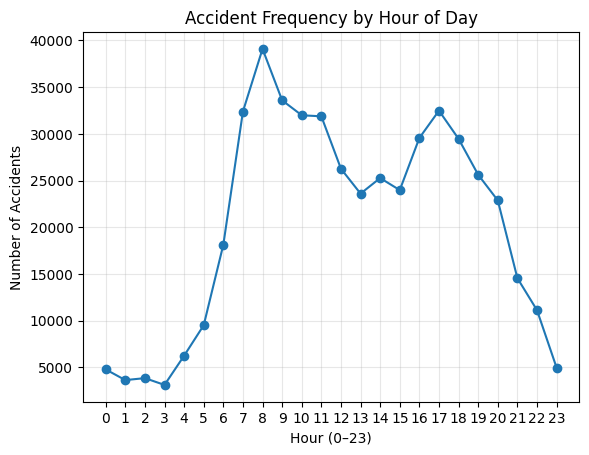

In [ ]:
hour_counts = df["Hour"].value_counts().sort_index()

plt.figure()
hour_counts.plot(marker="o")
plt.title("Accident Frequency by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

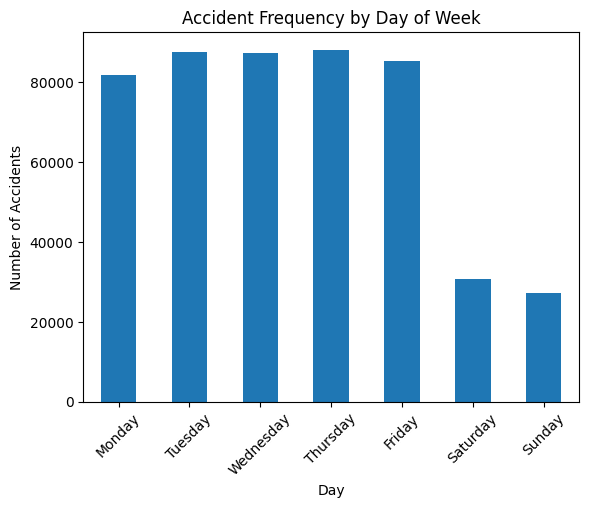

In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_counts = df["Day_of_Week"].value_counts().reindex(day_order)

plt.figure()
day_counts.plot(kind="bar")
plt.title("Accident Frequency by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown").str.lower()

def simplify_weather(x):
    if "rain" in x:
        return "Rain"
    elif "snow" in x or "ice" in x:
        return "Snow/Ice"
    elif "fog" in x or "mist" in x:
        return "Fog/Mist"
    elif "cloud" in x or "overcast" in x:
        return "Cloudy"
    elif "clear" in x:
        return "Clear"
    else:
        return "Other"

df["Weather_Group"] = df["Weather_Condition"].apply(simplify_weather)


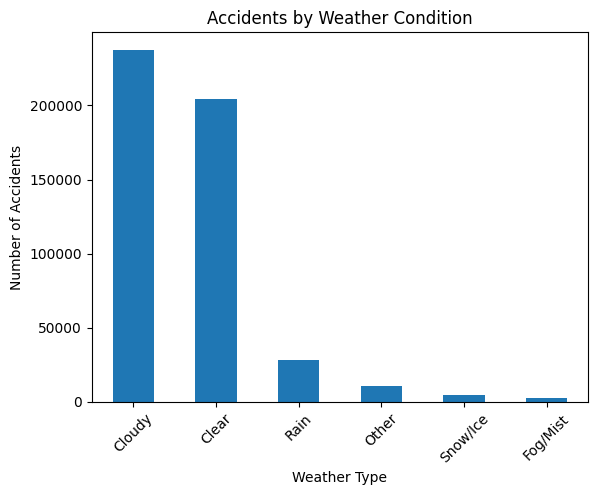

In [ ]:
weather_counts = df["Weather_Group"].value_counts()

plt.figure()
weather_counts.plot(kind="bar")
plt.title("Accidents by Weather Condition")
plt.xlabel("Weather Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

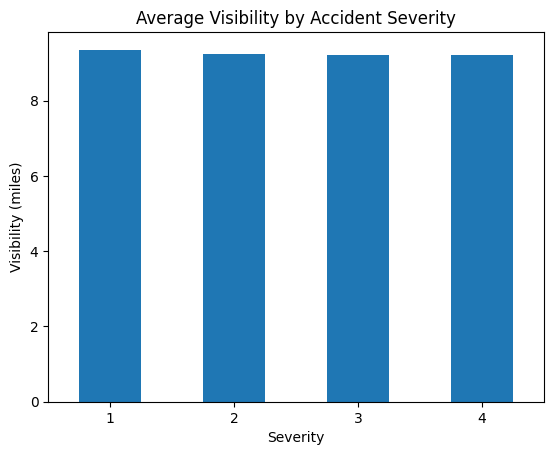

Severity
1    9.354111
2    9.235516
3    9.216204
4    9.213919
Name: Visibility(mi), dtype: float64


In [ ]:
vis_by_severity = df.groupby("Severity")["Visibility(mi)"].mean()

plt.figure()
vis_by_severity.plot(kind="bar")
plt.title("Average Visibility by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Visibility (miles)")
plt.xticks(rotation=0)
plt.show()

print(vis_by_severity)

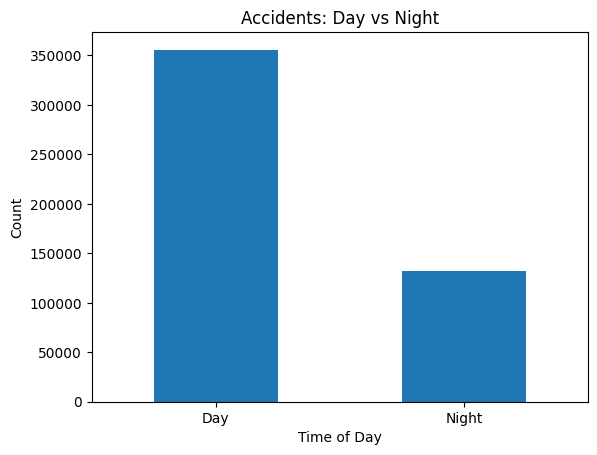

In [ ]:
day_night = df["Sunrise_Sunset"].value_counts()

plt.figure()
day_night.plot(kind="bar")
plt.title("Accidents: Day vs Night")
plt.xlabel("Time of Day")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.groupby("Sunrise_Sunset")["Severity"].mean()

,Severity
Sunrise_Sunset,
Day,2.362071
Night,2.402879


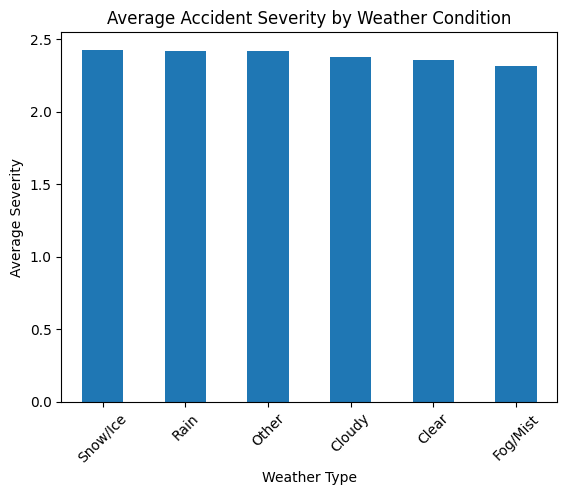

Weather_Group
Snow/Ice    2.426244
Rain        2.422050
Other       2.420056
Cloudy      2.376945
Clear       2.358901
Fog/Mist    2.316355
Name: Severity, dtype: float64


In [ ]:
weather_severity = df.groupby("Weather_Group")["Severity"].mean().sort_values(ascending=False)

plt.figure()
weather_severity.plot(kind="bar")
plt.title("Average Accident Severity by Weather Condition")
plt.xlabel("Weather Type")
plt.ylabel("Average Severity")
plt.xticks(rotation=45)
plt.show()

print(weather_severity)

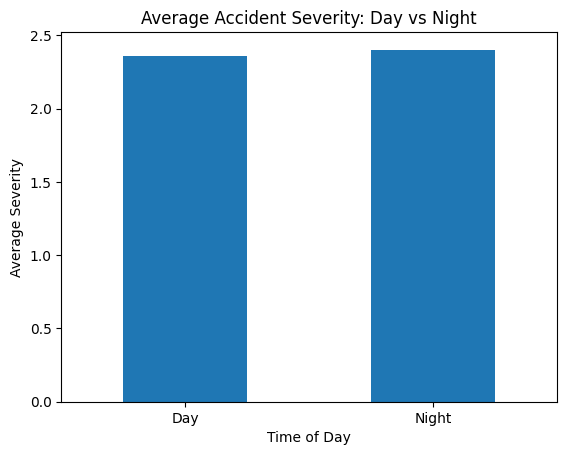

Sunrise_Sunset
Day      2.362071
Night    2.402879
Name: Severity, dtype: float64


In [ ]:
day_night_severity = df.groupby("Sunrise_Sunset")["Severity"].mean()

plt.figure()
day_night_severity.plot(kind="bar")
plt.title("Average Accident Severity: Day vs Night")
plt.xlabel("Time of Day")
plt.ylabel("Average Severity")
plt.xticks(rotation=0)
plt.show()

print(day_night_severity)

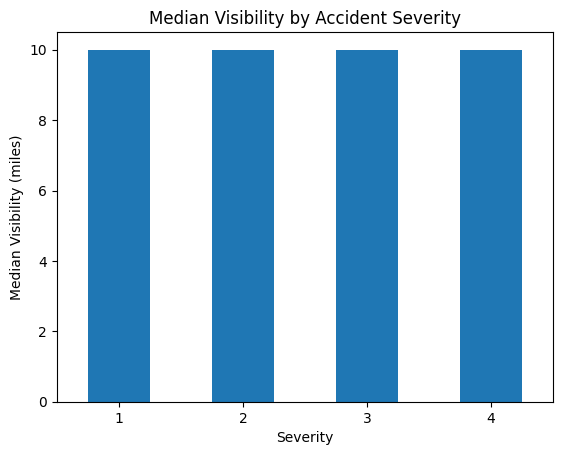

Severity
1    10.0
2    10.0
3    10.0
4    10.0
Name: Visibility(mi), dtype: float64


In [ ]:
vis_median = df.groupby("Severity")["Visibility(mi)"].median()

plt.figure()
vis_median.plot(kind="bar")
plt.title("Median Visibility by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Median Visibility (miles)")
plt.xticks(rotation=0)
plt.show()

print(vis_median)

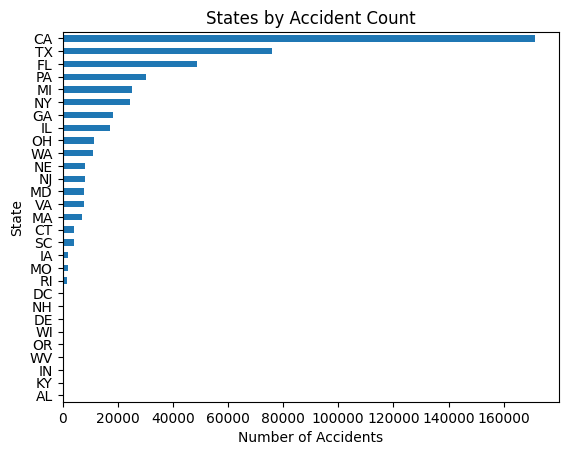

State
CA    171334
TX     76051
FL     48896
PA     30352
MI     25040
NY     24496
GA     18452
IL     17091
OH     11468
WA     11196
NE      8276
NJ      8009
MD      7931
VA      7767
MA      7196
CT      4094
SC      4035
IA      1986
MO      1909
RI      1523
DC       403
NH       150
DE       113
WI        67
OR        59
WV        44
IN        43
KY         5
AL         4
Name: count, dtype: int64


In [ ]:
state_counts = df["State"].value_counts()

plt.figure()
state_counts.sort_values().plot(kind="barh")
plt.title("States by Accident Count")
plt.xlabel("Number of Accidents")
plt.ylabel("State")
plt.show()

print(state_counts)

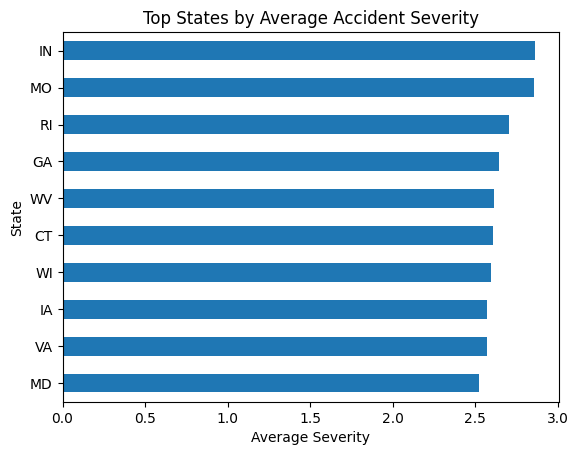

State
IN    2.860465
MO    2.853326
RI    2.706500
GA    2.640798
WV    2.613636
CT    2.606497
WI    2.597015
IA    2.570997
VA    2.570491
MD    2.521750
Name: Severity, dtype: float64


In [ ]:
state_severity = df.groupby("State")["Severity"].mean().sort_values(ascending=False).head(10)

plt.figure()
state_severity.sort_values().plot(kind="barh")
plt.title("Top States by Average Accident Severity")
plt.xlabel("Average Severity")
plt.ylabel("State")
plt.show()

print(state_severity)

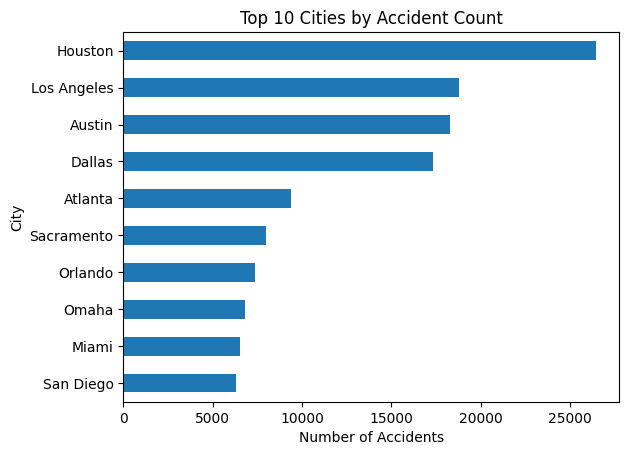

In [ ]:
city_counts = df["City"].value_counts().head(10)

plt.figure()
city_counts.sort_values().plot(kind="barh")
plt.title("Top 10 Cities by Accident Count")
plt.xlabel("Number of Accidents")
plt.ylabel("City")
plt.show()

In [ ]:
city_summary = df.groupby("City").agg({
    "Severity": "mean",
    "City": "count"
}).rename(columns={"City": "Accident_Count"})

# Filter for meaningful cities (avoid tiny ones)
city_summary = city_summary[city_summary["Accident_Count"] > 1000]

# Sort by severity
top_risky_cities = city_summary.sort_values("Severity", ascending=False).head(10)

top_risky_cities

,Severity,Accident_Count
City,,
Downey,2.959263,1031
Baldwin Park,2.950746,1340
Saint Louis,2.906564,1295
Albany,2.879139,1208
Fairfield,2.839702,1073
Fremont,2.817632,1157
Fort Worth,2.814020,1398
Fort Lauderdale,2.787575,1996
Oakland,2.785664,2846


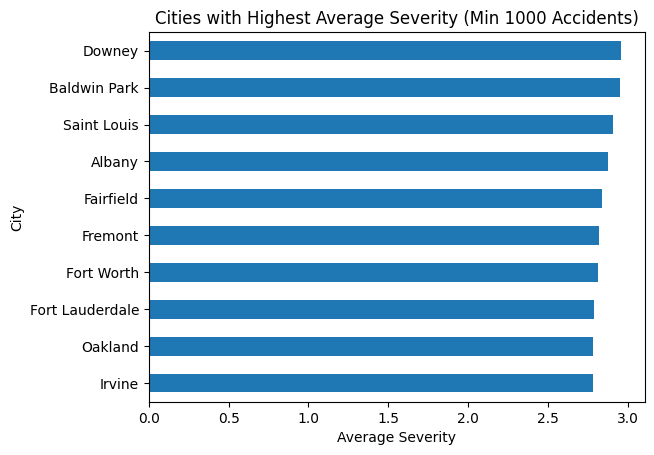

In [ ]:
top_risky_cities.sort_values("Severity").plot(
    kind="barh", y="Severity", legend=False
)
plt.title("Cities with Highest Average Severity (Min 1000 Accidents)")
plt.xlabel("Average Severity")
plt.ylabel("City")
plt.show()

## Analysis

Exploratory analysis was performed to identify patterns in accident frequency and severity across time, environmental conditions, and geography. Temporal trends showed that accidents were concentrated during weekday commuting hours, particularly in the morning and late afternoon, indicating that traffic volume is a major driver of crash frequency. Geographic analysis found that highly populated states such as California, Texas, and Florida reported the greatest number of accidents, while some smaller states and cities showed higher average severity, suggesting that local road conditions or traffic environments may influence outcomes.

Environmental factors were also examined using weather condition, visibility, and day/night status. Rain, snow, and nighttime driving were associated with slightly higher average accident severity, but the differences were modest compared with the stronger patterns seen in time-based and location-based trends. Visibility alone showed limited separation across severity levels, indicating that no single weather variable fully explains accident outcomes. Overall, the results suggest that accident risk is shaped most heavily by when and where people travel, while environmental conditions act as contributing factors rather than primary drivers.


## Evaluation

### Business Insight/Recommendation 1

**Insight**: Accidents Peak During Commuting Hours (Rush Hour)

Accident frequency shows a clear concentration during morning and evening commute periods, with peaks typically occurring between 6–9 AM and 4–7 PM on weekdays. This suggests that increased traffic density and congestion are major contributors to accident frequency. The Department of Transportation should prioritize traffic monitoring, enforcement, and congestion mitigation strategies during peak commuting hours to reduce accident risk.

### Business Insight/Recommendation 2

**Insight**: Environmental factors show limited influence on accident severity, with only minor increases observed under nighttime and certain adverse weather conditions.

Analysis of environmental conditions indicates that accident severity is relatively consistent across different visibility levels, with median visibility remaining constant across all severity categories. This suggests that visibility alone is not a strong differentiating factor in accident severity within this dataset. While accidents occurring at night and during adverse weather conditions such as rain and snow show slightly higher average severity, the differences are modest. This indicates that environmental conditions may contribute to accident severity, but are not the primary drivers compared to other factors such as traffic density, driver behavior, or roadway design.

The Department of Transportation should prioritize traffic management and infrastructure improvements over weather-specific interventions, continue implementing nighttime safety measures (improved lighting, reflective signage),use weather data as a secondary risk indicator and invest in further analysis incorporating traffic volume and roadway design data which may better explain severity differences.

### Business Insight/Recommendation 3

**Insight**: Accident severity varies geographically, with certain states and cities showing consistently higher severity levels.

Analysis of accident severity across states and cities reveals that some regions experience more severe accidents on average, even when controlling for accident volume. This suggests that local factors such as road design, traffic patterns, and infrastructure may contribute to more dangerous driving conditions. The Department of Transportation should prioritize safety audits in high-severity regions, improve roadway design in high-risk cities, increase targeted enforcement and monitoring, and allocate funding toward infrastructure improvements in these areas.

In [ ]:
df.to_csv("accident_analysis_500k.csv", index=False)

print("File exported successfully: accident_analysis_500k.csv")

File exported successfully: accident_analysis_500k.csv


In [ ]:
from google.colab import files
files.download("accident_analysis_500k.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Tableau Dashboard link

https://public.tableau.com/views/U_S_AccidentAnalysis/LocationAnalysis?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

## Conclusion and Next Steps
This project analyzed a 500,000-record sample from the U.S. Accidents dataset to identify meaningful trends in accident timing, environmental conditions, and geographic distribution. While the full dataset contains several million records, a reduced sample was used due to local computer processing limitations. Even with this smaller subset, the dataset was large enough to uncover clear and actionable patterns.

The strongest finding was that accident frequency is driven more by traffic exposure than by weather severity alone. Highly populated states and urban regions reported the largest number of accidents, reinforcing that population density and roadway volume are major contributors to crash frequency. Similarly, accidents were most common during peak commuting hours, especially weekday morning and late afternoon travel periods, when traffic congestion is highest. These patterns suggest that the number of vehicles on the road plays a larger role in accident volume than isolated environmental factors.

Another key insight was that better driving conditions often coincide with more accidents, likley because more people are traveling. High-visibility and clear-weather conditions produced many crashes, probably because they represent normal driving conditions with greater traffic activity. In contrast, weather variables such as rain, snow, and reduced visibility showed only modest differences in average severity. This suggests that while weather can contribute to risk, it may be a secondary factor compared with traffic density, speed, infrastructure, and/or driver behavior.

Future improvements could include analyzing the full dataset using stronger computing resources, incorporating additional variables such as road type, speed limits, and traffic volume, and building predictive models for accident severity or hotspot detection. Expanding the project with machine learning and real-time traffic data could provide even stronger decision-making tools for transportation agencies, insurers, law enforcement, and city planners.